# Co-training report

Plots **detector** validation metrics (`metrics_final.json` rolled into `round_summaries.jsonl`) and **deslop** slop-score aggregates per round.

**Colab:** clone or upload the repo, `cd` into `promptlab-v2`, run training there, then open this notebook with the **same working directory** (or set `REPO_ROOT` below to the folder that contains `outputs/`).

**Local Mac:** run the first cell after `cd promptlab-v2` so `outputs/` resolves correctly.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Folder that contains outputs/cotrain/ (project root = promptlab-v2)
REPO_ROOT = Path("/Users/ianlent/Proj_Attempt2_Stat-4830/promptlab-v2")

# Colab example if you cloned to /content/promptlab-v2:
# REPO_ROOT = Path("/content/promptlab-v2")

SUMMARY_PATH = REPO_ROOT / "outputs" / "cotrain" / "round_summaries.jsonl"
DETECTOR_ROOT = REPO_ROOT / "outputs" / "detector_cotrain"

print("REPO_ROOT:", REPO_ROOT)
print("Summaries:", SUMMARY_PATH, "exists:", SUMMARY_PATH.is_file())

REPO_ROOT: /Users/ianlent/Proj_Attempt2_Stat-4830/promptlab-v2
Summaries: /Users/ianlent/Proj_Attempt2_Stat-4830/promptlab-v2/outputs/cotrain/round_summaries.jsonl exists: True


In [3]:
def load_round_summaries(path: Path) -> pd.DataFrame:
    rows: list[dict] = []
    if not path.is_file():
        return pd.DataFrame(rows)
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)


def merge_metrics_from_disk(df: pd.DataFrame, detector_root: Path) -> pd.DataFrame:
    """Fill missing detector_metrics from outputs/detector_cotrain/round_r/metrics_final.json (e.g. old summaries or Colab copy)."""
    if df.empty:
        return df
    out = df.copy()
    for i, row in out.iterrows():
        dm = row.get("detector_metrics")
        if dm is not None and isinstance(dm, dict):
            continue
        r = int(row.get("round", 0))
        if r <= 0:
            continue
        mf = detector_root / f"round_{r}" / "metrics_final.json"
        if mf.is_file():
            out.at[i, "detector_metrics"] = json.loads(mf.read_text(encoding="utf-8"))
    return out


df = load_round_summaries(SUMMARY_PATH)
df = merge_metrics_from_disk(df, DETECTOR_ROOT)
if df.empty:
    raise SystemExit("No rows in round_summaries.jsonl — run cotrain or point REPO_ROOT at your artifacts.")

# Old/partial runs may omit nested keys — pandas won't create columns; plots still work with NaNs.
for _col in ("detector_metrics", "deslop_slop_stats", "binary_threshold"):
    if _col not in df.columns:
        df[_col] = None

df["round"] = df["round"].astype(int)
df = df.sort_values("round").reset_index(drop=True)

def dm_col(key: str) -> pd.Series:
    col = df["detector_metrics"]
    return col.apply(lambda m: (m or {}).get(key) if isinstance(m, dict) else None)

df["val_loss"] = dm_col("loss")
df["val_macro_f1"] = dm_col("macro_f1")
df["val_accuracy"] = dm_col("accuracy")
df["val_roc_auc"] = dm_col("roc_auc")

def stat_col(name: str) -> pd.Series:
    return df["deslop_slop_stats"].apply(lambda s: (s or {}).get(name) if isinstance(s, dict) else None)

df["deslop_mean_slop"] = stat_col("mean")
df["deslop_pct_below_threshold"] = stat_col("pct_below_threshold")
df["deslop_n_scored"] = stat_col("count")

for c in ["val_loss", "val_macro_f1", "val_accuracy", "val_roc_auc", "deslop_mean_slop", "deslop_pct_below_threshold"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df

,round,optimizer_best_mean_slop,mean_fitness,n_fool,detector_path,detector_metrics,deslop_slop_stats,binary_threshold,val_loss,val_macro_f1,val_accuracy,val_roc_auc,deslop_mean_slop,deslop_pct_below_threshold,deslop_n_scored
0,1,0.401387,-0.242253,2,pangram/editlens_roberta-large,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None


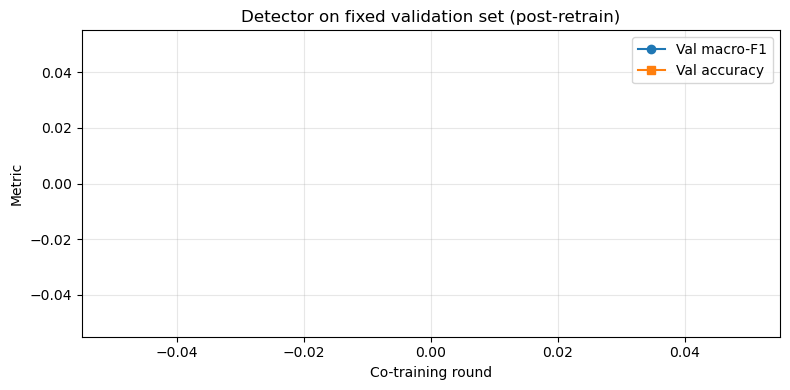

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["round"], df["val_macro_f1"], marker="o", label="Val macro-F1")
ax.plot(df["round"], df["val_accuracy"], marker="s", label="Val accuracy")
if df["val_roc_auc"].notna().any():
    ax.plot(df["round"], df["val_roc_auc"], marker="^", label="Val ROC-AUC (binary)")
ax.set_xlabel("Co-training round")
ax.set_ylabel("Metric")
ax.set_title("Detector on fixed validation set (post-retrain)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

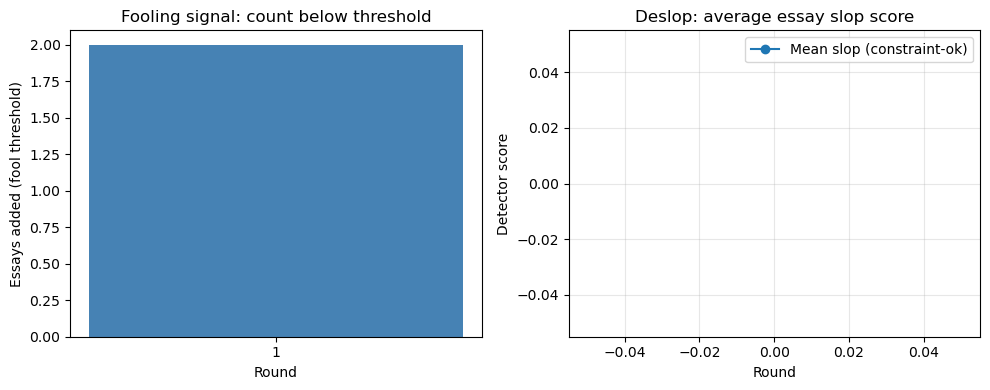

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df["round"].astype(str), df["n_fool"], color="steelblue")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Essays added (fool threshold)")
axes[0].set_title("Fooling signal: count below threshold")

axes[1].plot(df["round"], df["deslop_mean_slop"], marker="o", label="Mean slop (constraint-ok)")
if df["binary_threshold"].notna().any():
    th = float(df["binary_threshold"].dropna().iloc[0])
    axes[1].axhline(th, color="red", linestyle="--", alpha=0.7, label=f"Threshold ({th})")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Detector score")
axes[1].set_title("Deslop: average essay slop score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

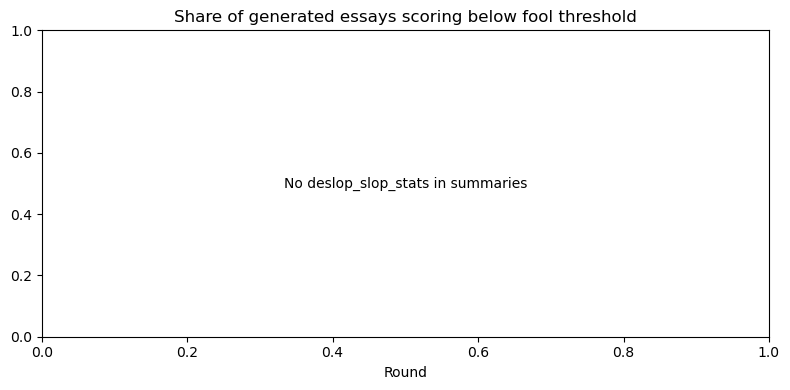

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
pct = df["deslop_pct_below_threshold"]
if pct.notna().any():
    ax.bar(df["round"].astype(str), (pct * 100.0).fillna(0), color="seagreen")
    ax.set_ylabel("Percent of constraint-ok essays")
else:
    ax.text(0.5, 0.5, "No deslop_slop_stats in summaries", ha="center", va="center")
ax.set_xlabel("Round")
ax.set_title("Share of generated essays scoring below fool threshold")
plt.tight_layout()
plt.show()

### Optional: val loss only
If `val_loss` is present (from `metrics_final.json`), plot it alongside F1.

In [ ]:
if df["val_loss"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(df["round"], df["val_loss"], marker="o", color="darkorange")
    ax.set_xlabel("Round")
    ax.set_ylabel("Eval loss")
    ax.set_title("Detector validation loss (end of retrain)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No val_loss in detector_metrics — train with updated detector/train.py")